# Model V2 — AR(1) with Annual Cycle, New Year Effect, and Full Reset

**Likelihood:**
$$y_{i,1} \sim \mathcal{N}(\mu_{i,1},\, \tau_i)$$
$$y_{i,t} \sim \mathcal{N}\!\Big(\mu_{i,t} + \phi\,(y_{i,t-1} - \mu_{i,t-1}),\, \tau_i\Big), \quad t = 2,\ldots,T$$

**Mean function:**
$$\mu_{i,t} = \alpha_i + \beta_i \cos\!\Big(\frac{2\pi t}{52}\Big) + \gamma_i \sin\!\Big(\frac{2\pi t}{52}\Big) + $$ $$\delta_{\text{pre}}\, \mathbb{1}(t\mod 52 = 0) + \delta_{\text{mid}}\, \mathbb{1}(t\mod 52 = 1) + \delta_{\text{post}}\, \mathbb{1}(t \mod 52 = 2) + $$ $$\sigma_{\text{pre}}\, \mathbb{1}(t = 86, i=\text{mid west}) + \sigma_{\text{mid}}\, \mathbb{1}(t = 87, i=\text{mid west}) + \sigma_{\text{post}}\, \mathbb{1}(t = 88, i=\text{mid west})$$

Where $m_i = 1$ if region $i$ is HSE Mid West, $0$ otherwise.

**Priors:**
$$\alpha_i, \beta_i, \gamma_i \sim \mathcal{N}(0,\, 10^3) \quad \tau_i \sim \text{Gamma}(0.001,\, 0.001) \quad \phi \sim \text{Uniform}(-1,\, 1)$$
$$\delta_{\text{pre}},\, \delta_{\text{mid}},\, \delta_{\text{post}},\, \sigma_{\text{pre}},\, \sigma_{\text{mid}},\, \sigma_{\text{post}} \sim \mathcal{N}(0,\, 10^3)$$

In [320]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np
from itertools import combinations

sns.set_theme(style="whitegrid", font_scale=1.2) 

# Load raw MCMC samples and compute model parameters
df_og=pd.read_csv('../../data/wide_weekly_scaledPer10k.csv')
# Load raw MCMC samples and compute model parameters
raw_df = pd.read_csv('../../data/models/v2/raw_samples.csv')
regions = pd.read_csv('../../data/regions.csv')['region'].tolist()
n_region = len(regions)

## Load the model parameters

In [321]:
n_weeks = df_og.shape[1] - 1  # exclude Region column

# Time vector (1-based, matching R)
t_vec = np.arange(1, n_weeks + 1)

# Event indicators (matching R model specification)
week_mod = t_vec % 52
ny_pre  = (week_mod == 0).astype(float)
ny_mid  = (week_mod == 1).astype(float)
ny_post = (week_mod == 2).astype(float)
fr_pre  = (t_vec == 86).astype(float)
fr_mid  = (t_vec == 87).astype(float)
fr_post = (t_vec == 88).astype(float)
mw = np.array([1.0 if r == 'HSE Mid West' else 0.0 for r in regions])

# Compute mu[i,t] from raw samples: mean and 2.5%/97.5% CIs
cos_t = np.cos(2 * np.pi * t_vec / 52)
sin_t = np.sin(2 * np.pi * t_vec / 52)

mu_mean_arr = np.zeros((n_weeks, n_region))
mu_lower_arr = np.zeros((n_weeks, n_region))
mu_upper_arr = np.zeros((n_weeks, n_region))

for i in range(n_region):
    mu_i = (raw_df[f'alpha[{i+1}]'].values[:, None]
            + raw_df[f'beta[{i+1}]'].values[:, None] * cos_t[None, :]
            + raw_df[f'gamma[{i+1}]'].values[:, None] * sin_t[None, :]
            + raw_df['delta_pre'].values[:, None] * ny_pre[None, :]
            + raw_df['delta_mid'].values[:, None] * ny_mid[None, :]
            + raw_df['delta_post'].values[:, None] * ny_post[None, :]
            + raw_df['sigma_pre'].values[:, None] * (fr_pre * mw[i])[None, :]
            + raw_df['sigma_mid'].values[:, None] * (fr_mid * mw[i])[None, :]
            + raw_df['sigma_post'].values[:, None] * (fr_post * mw[i])[None, :])
    mu_mean_arr[:, i] = mu_i.mean(axis=0)
    mu_lower_arr[:, i] = np.quantile(mu_i, 0.025, axis=0)
    mu_upper_arr[:, i] = np.quantile(mu_i, 0.975, axis=0)

df_mu = pd.DataFrame(mu_mean_arr, columns=regions)
df_mu_lower = pd.DataFrame(mu_lower_arr, columns=regions)
df_mu_upper = pd.DataFrame(mu_upper_arr, columns=regions)

# Scalar parameter means
phi_mean = raw_df['phi'].mean()

# Alpha summary for export
df_alpha = pd.DataFrame({
    'Mean': [raw_df[f'alpha[{i+1}]'].mean() for i in range(n_region)],
    'SD': [raw_df[f'alpha[{i+1}]'].std() for i in range(n_region)],
}, index=regions)

## Preprocess
Transform the og df into regions (cols) x time (weeks) 

In [322]:
df_og=df_og.T
df_og.columns=df_og.iloc[0]
df_og=df_og.drop(df_og.index[0])
df_og=df_og.reset_index(drop=True)

## Make the model estimate df
Formula
y[i,t] ~ dnorm(mu[i,t] + (phi * (y[i,t-1] - mu[i,t-1])), tau[i])

In [323]:
# Make the t-1 df
df_mu_t1 = df_mu.iloc[:df_mu.shape[0]-1]
df_og_t1 = df_og.iloc[:df_mu.shape[0]-1]
# Extract phi
phi = phi_mean
# Extract first mu
df_mu_first = pd.DataFrame([df_mu.iloc[0]])
# Extract not first mu
df_mu_rest = df_mu.iloc[1:].reset_index(drop=True)
# Calculate AR(1)
df_ar1 = df_mu_rest + (phi * (df_og_t1 - df_mu_t1))
df_ar1 = pd.concat([df_mu_first, df_ar1], ignore_index=True)
df_ar1

,HSE Dublin and Midlands,HSE Dublin and North East,HSE Dublin and South East,HSE Mid West,HSE South West,HSE West and North West
0,1.306479,-0.183117,0.452367,4.411306,1.999755,3.120979
1,4.579356,3.855127,4.054551,5.819425,4.871175,5.423219
2,6.089754,4.253694,5.151285,7.21026,6.433901,9.059344
3,5.313771,3.242406,4.250794,5.275999,5.100587,6.216492
4,5.169293,2.67226,3.641877,5.832304,5.108179,7.474128
...,...,...,...,...,...,...
146,2.927043,1.989258,2.977116,7.191108,5.057217,6.619889
147,2.495153,1.76787,3.127552,5.590268,5.392438,5.271356
148,2.525668,1.822296,3.096011,5.088207,4.555155,5.796212
149,2.927959,1.966848,3.035237,5.434461,5.076896,5.317062


## Plot MU
This should look like yearly oscillations

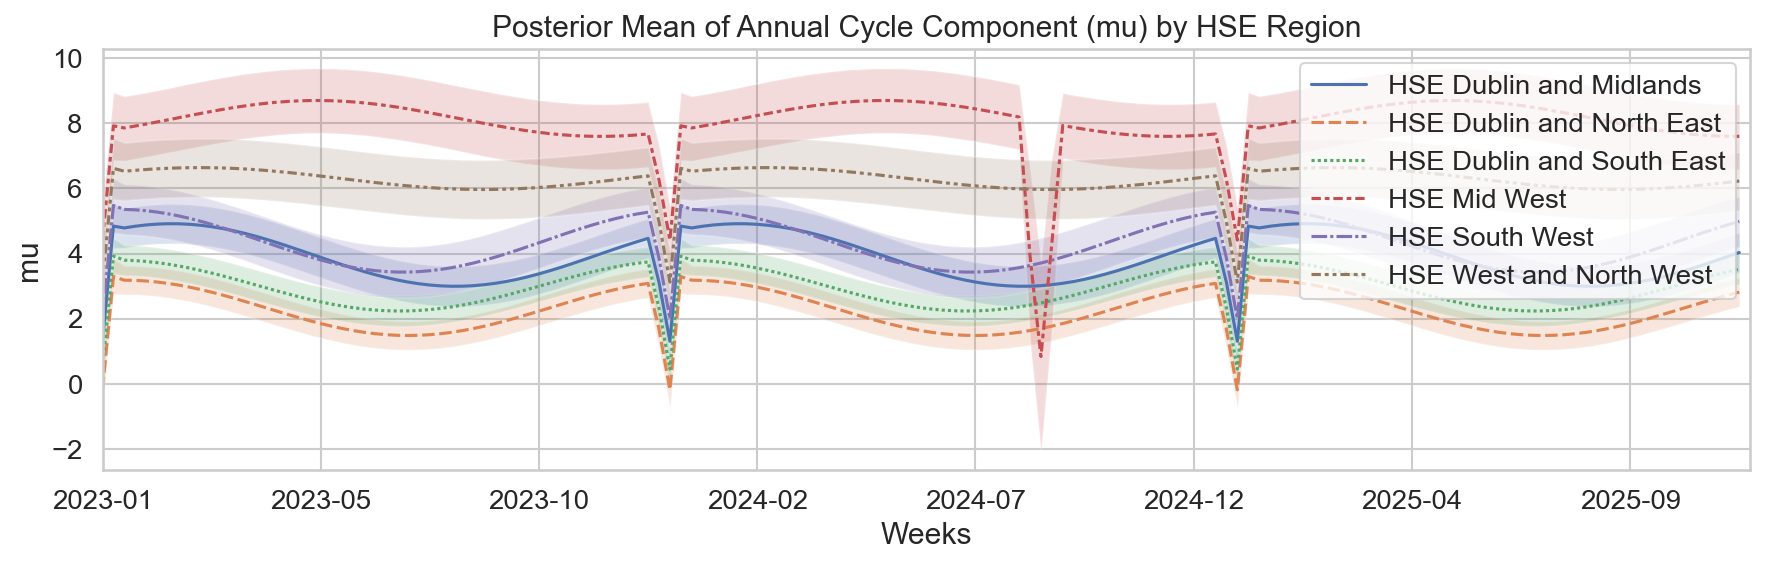

In [324]:
plt.figure(figsize=(12, 4), dpi=150)
# convert mu index to datetime
# df_mu.index=pd.to_datetime('2023-01-01') + pd.to_timedelta(df_mu.index, unit='W')
# plot data
axs = sns.lineplot(data=df_mu)
# plot ci
for col in df_mu.columns:
    # plt.plot(df_mu.index, df_mu[col], label=col)
    plt.fill_between(df_mu.index, df_mu_lower[col], df_mu_upper[col], alpha=0.2)
# annotations--------
# vertical lines
axs.set_title('Posterior Mean of Annual Cycle Component (mu) by HSE Region')
axs.set_xlabel('Weeks')
axs.set_ylabel('mu')
axs.set_xlim(0, df_mu.shape[0])
# Set x-ticks and labels
axs.set_xticks(df_mu.index[::20])
x_labels = pd.to_datetime('2023-01-01') + pd.to_timedelta(df_mu.index, unit='W')
x_labels = x_labels.strftime('%Y-%m')
axs.set_xticklabels(x_labels[::20])
plt.legend(loc='upper right')
#get handles and labels
handles, labels = plt.gca().get_legend_handles_labels()
#specify order of items in legend
order = [3,5,4,0,2,1]
#add legend to plot
# region_order = [handles[idx] for idx in order],[labels[idx] for idx in order]
# plt.legend(region_order) 
plt.tight_layout()

### CI Validation
CI's Look Uniform/Unchanging...

Display 2.5% - 97.5% Credible Intervals To Validate that they are different, time point to time point

In [325]:
# Show the residuals for HSE Mid West
pd.concat([df_mu_lower.rename(columns={'HSE Dublin and Midlands': 'HSE Dublin and Midlands: Lower CI'})['HSE Dublin and Midlands: Lower CI'],\
           df_mu_upper.rename(columns={'HSE Dublin and Midlands': 'HSE Dublin and Midlands: Upper CI'})['HSE Dublin and Midlands: Upper CI'],\
           df_mu_lower.rename(columns={'HSE Dublin and North East': 'HSE Dublin and North East: Lower CI'})['HSE Dublin and North East: Lower CI'],\
           df_mu_upper.rename(columns={'HSE Dublin and North East': 'HSE Dublin and North East: Upper CI'})['HSE Dublin and North East: Upper CI'],\
           df_mu_lower.rename(columns={'HSE Mid West': 'HSE Mid West: Lower CI'})['HSE Mid West: Lower CI'],\
           df_mu_upper.rename(columns={'HSE Mid West': 'HSE Mid West: Upper CI'})['HSE Mid West: Upper CI']],\
            axis=1)

,HSE Dublin and Midlands: Lower CI,HSE Dublin and Midlands: Upper CI,HSE Dublin and North East: Lower CI,HSE Dublin and North East: Upper CI,HSE Mid West: Lower CI,HSE Mid West: Upper CI
0,0.628306,1.986198,-0.725246,0.358141,3.360147,5.438952
1,4.170558,5.518403,2.766395,3.833889,6.873445,8.943196
2,4.184232,5.386037,2.748526,3.623442,6.856570,8.828467
3,4.237904,5.441074,2.742913,3.615173,6.917900,8.883933
4,4.277905,5.480866,2.725148,3.595673,6.979480,8.942374
...,...,...,...,...,...,...
146,2.965996,4.183732,2.000172,2.881437,6.645815,8.641780
147,3.076599,4.291505,2.101705,2.982389,6.622724,8.612082
148,3.189919,4.402920,2.197592,3.080570,6.603829,8.594555
149,3.306364,4.517415,2.289488,3.171899,6.591331,8.585012


## Alpha baseline

In [326]:
df_alpha.sort_values('Mean', ascending=False).round(2).to_excel('~/Downloads/alpha_values.xlsx')

## Plot Full Model

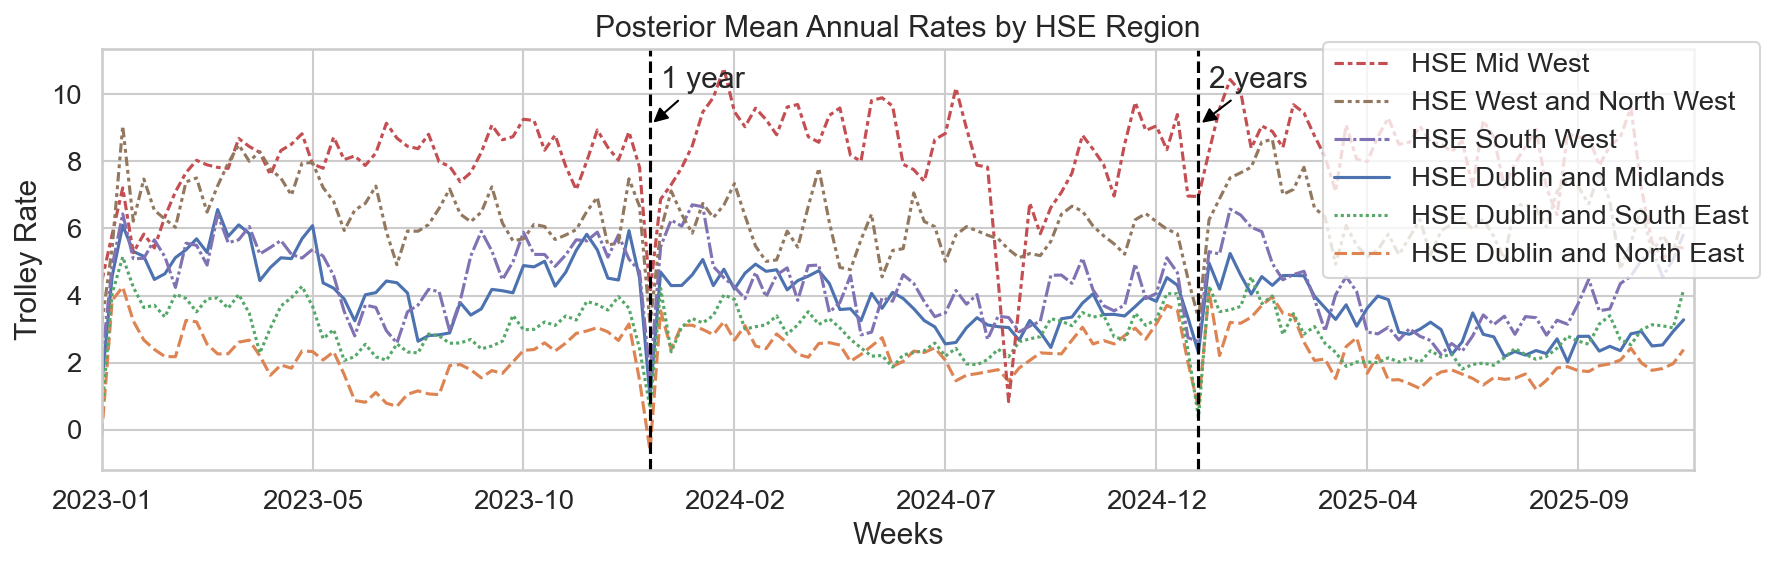

In [327]:
plt.figure(figsize=(12, 4), dpi=150)

axs = sns.lineplot(data=df_ar1)

axs.axvline(x=104, color='black', linestyle='--')
axs.axvline(x=52, color='black', linestyle='--')

axs.annotate('2 years', xy=(104, plt.ylim()[1]*0.8), xytext=(105, plt.ylim()[1]*.90), arrowprops=dict(arrowstyle='-|>', color='black'))
axs.annotate('1 year',  xy=(52,  plt.ylim()[1]*0.8), xytext=(53, plt.ylim()[1]*.90),  arrowprops=dict(arrowstyle='-|>', color='black'))

axs.set_xlim(0, df_ar1.shape[0])

axs.set_title('Posterior Mean Annual Rates by HSE Region')
axs.set_xlabel('Weeks')
axs.set_ylabel('Trolley Rate')

# Set x-ticks and labels
axs.set_xticks(df_ar1.index[::20])
x_labels = pd.to_datetime('2023-01-01') + pd.to_timedelta(df_ar1.index, unit='W')
x_labels = x_labels.strftime('%Y-%m')
axs.set_xticklabels(x_labels[::20])

#get handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

#specify order of items in legend
order = [3,5,4,0,2,1]

#add legend to plot
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order],\
            loc='upper right', bbox_to_anchor=(1.05, 1.05))

# plt.legend(loc='upper right')
plt.tight_layout()

## Plot the residuals

### Calculate data frame of residuals

In [328]:
df_residuals = df_og - df_ar1
df_std_resid = df_residuals / df_residuals.std()

### Plot

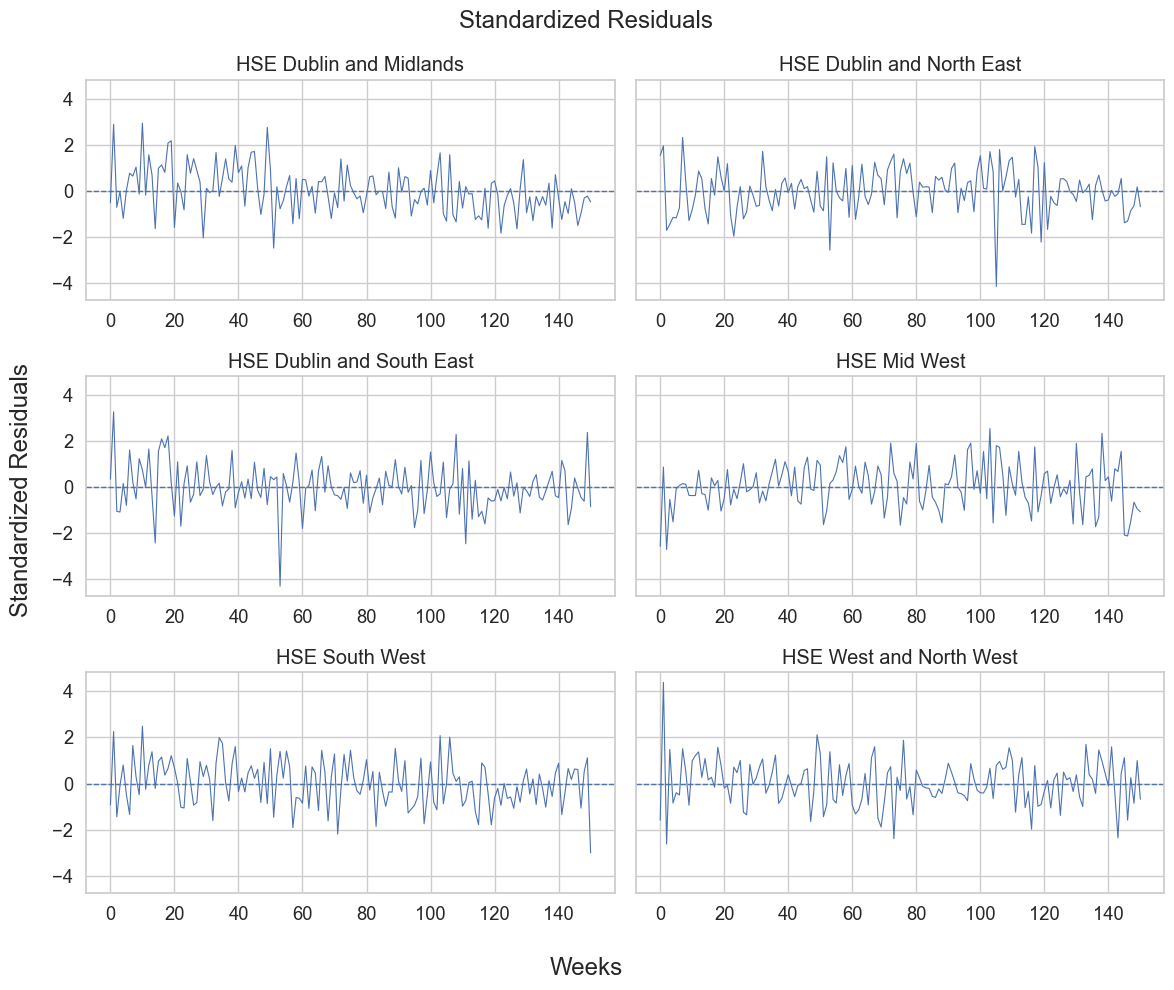

In [329]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey=True)

for col, ax in zip(df_std_resid.columns, axes.flatten()):
    ax.plot(df_std_resid[col], linewidth=0.8)
    ax.axhline(y=0, linestyle='--', linewidth=1)
    ax.set_title(col)
    ax.set_ylabel('')
    ax.set_xlabel('')

fig.suptitle('Standardized Residuals')
fig.supxlabel('Weeks')
fig.supylabel('Standardized Residuals')
plt.tight_layout()

### Autocorrelation of Residuals

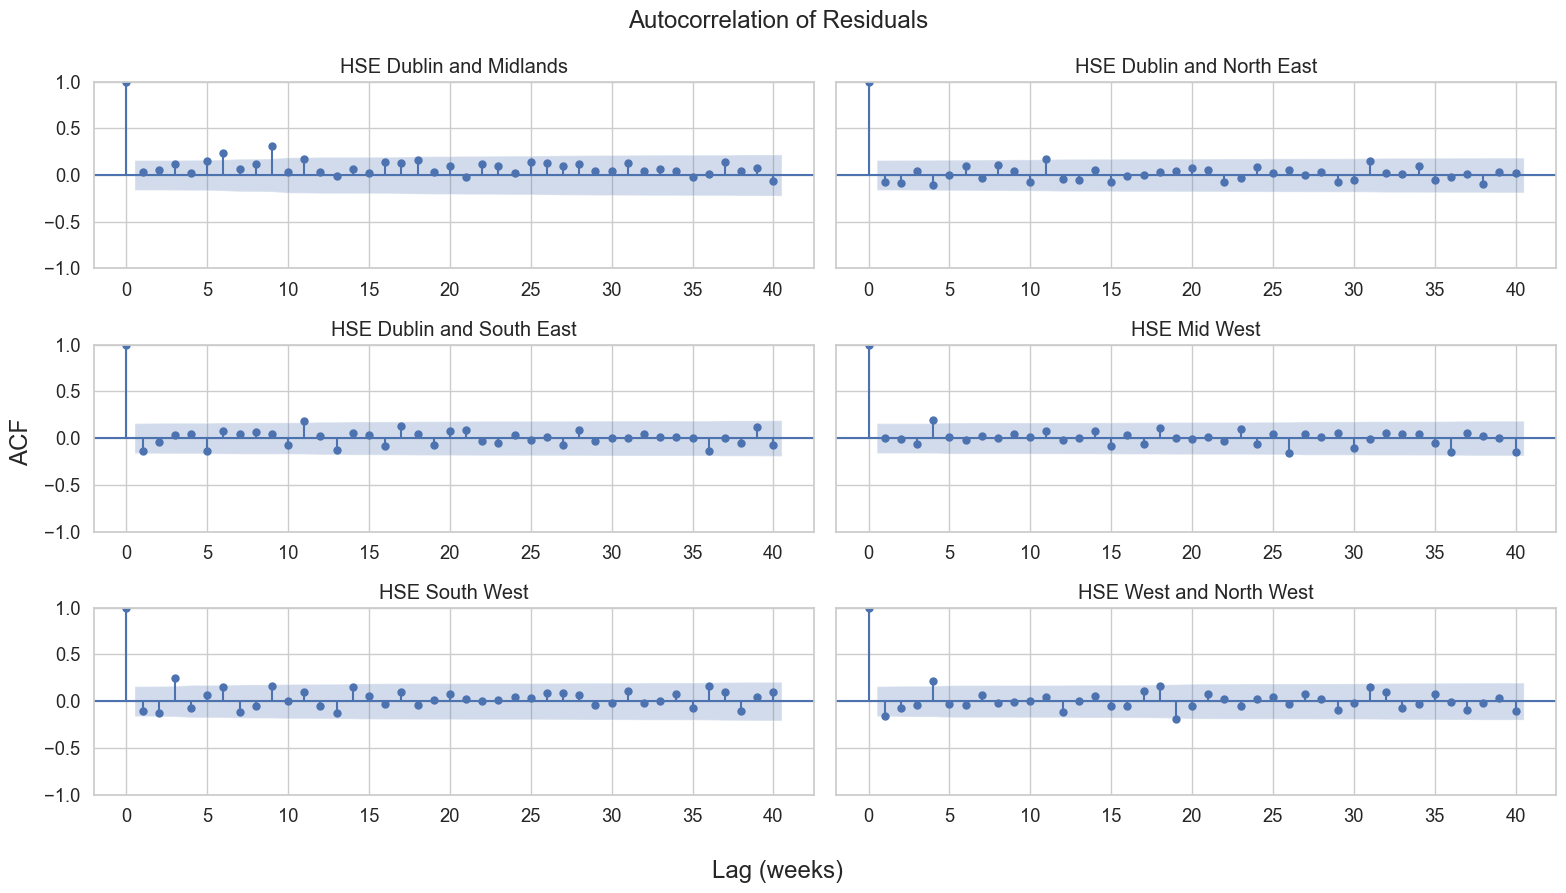

In [330]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(3, 2, figsize=(16, 9), sharey=True)
for ax, col in zip(axes.flatten(), df_std_resid.columns):
    plot_acf(df_std_resid[col].dropna(), ax=ax, lags=40, alpha=0.05)
    ax.set_title(col)
    ax.set_ylabel('')
    ax.set_xlabel('')

fig.suptitle('Autocorrelation of Residuals')
fig.supxlabel('Lag (weeks)')
fig.supylabel('ACF')
plt.tight_layout()

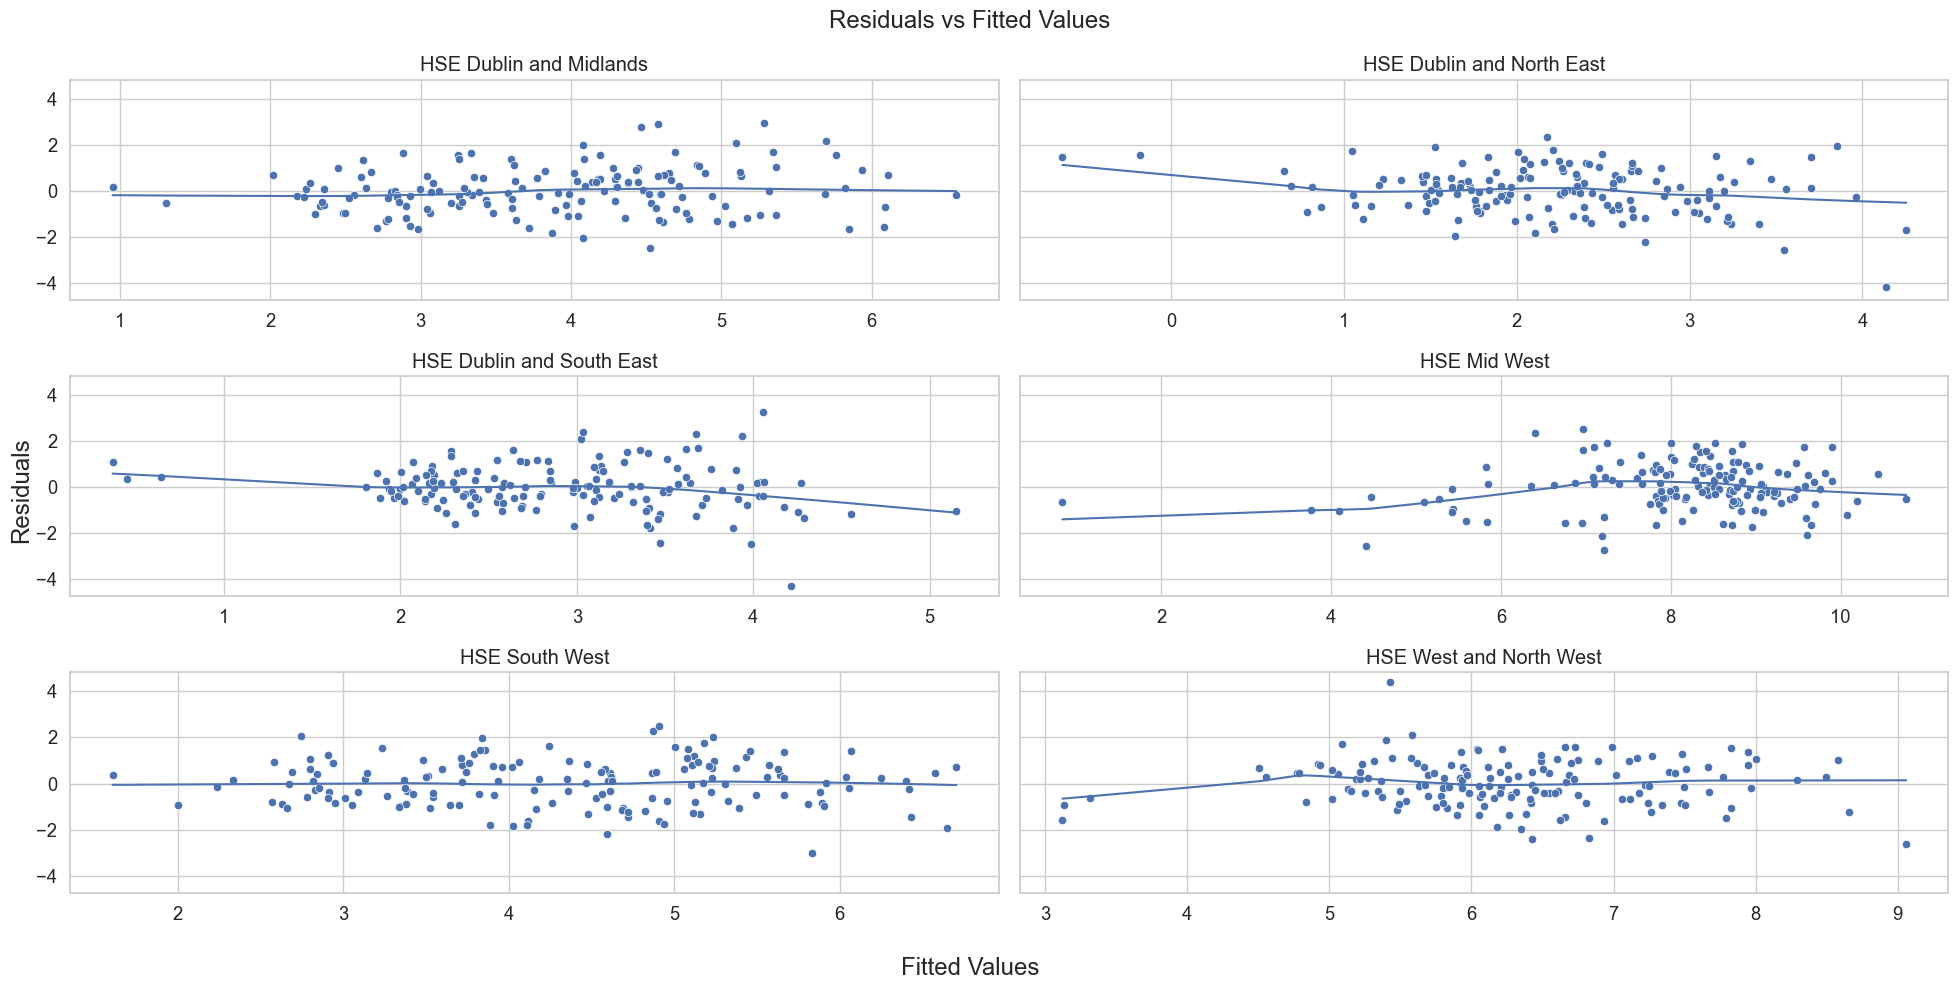

In [331]:
# annotation text
y_loc=.7; x_shift=10
fig, axes = plt.subplots(3, 2, figsize=(20, 10), sharey=True)

for col, ax in zip(df_std_resid.columns, axes.flatten()):

    sns.scatterplot(x=df_ar1[col], y=df_std_resid[col], ax=ax)
    # for col in df_std_resid.columns:
    smooth = lowess(df_std_resid[col], df_ar1[col], frac=2/3, return_sorted=True)
    sns.lineplot(x=smooth[:,0], y=smooth[:,1], ax=ax)

    ax.annotate('2 years', xy=(104, plt.ylim()[1]*y_loc), xytext=(104+x_shift, plt.ylim()[1]*y_loc), arrowprops=dict(arrowstyle='-|>', color='black'))
    ax.annotate('1 year',  xy=(52,  plt.ylim()[1]*y_loc), xytext=(52 +x_shift, plt.ylim()[1]*y_loc), arrowprops=dict(arrowstyle='-|>', color='black'))

    ax.set_title(col)
    ax.set_ylabel('')
    ax.set_xlabel('')

fig.suptitle('Residuals vs Fitted Values')
fig.supxlabel('Fitted Values')
fig.supylabel('Residuals')

plt.tight_layout()

### Notes
* Yearly shock not captured by the AR1 oscillatory components. Likely too high a frequency for a 52 width sinusoid(?).
* Overall Looks like the residuals have a normal variance. Stays tight to the 0 point.

### QQ-Plot For Residuals

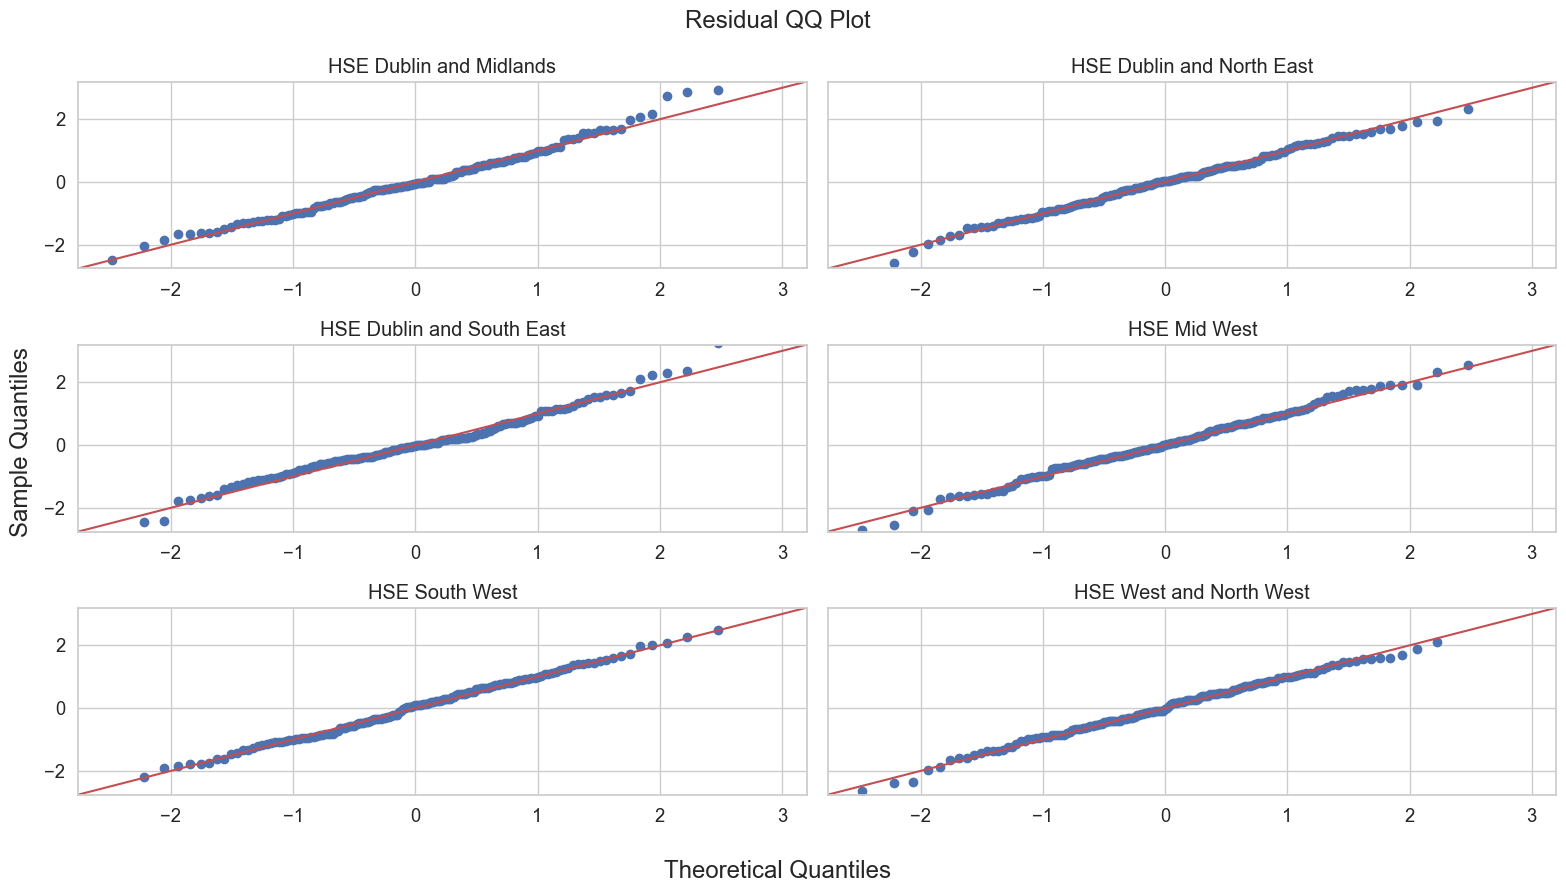

In [332]:
# Q-Q plot
fig, axes = plt.subplots(3, 2, figsize=(16, 9), sharey=True)
for i, (ax, col) in enumerate(zip(axes.flatten(), df_std_resid.columns)):
    qqplot(df_std_resid[col], line='45', ax=ax)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(col)

fig.suptitle('Residual QQ Plot')
fig.supxlabel('Theoretical Quantiles')
fig.supylabel('Sample Quantiles')
plt.tight_layout()


# Significance Testing
Overall:
$$H_0:X=0$$
$$H_a:X\neq0$$
Pairwise:
$$H_0:X_1-X_2=0$$
$$H_a:X_1-X_2\neq0$$

In [333]:
def calc_bonf(n_comparisons, one_sided=False):
    alpha = 0.05 / n_comparisons
    if one_sided:
        lower_q = alpha       # one-sided: full alpha in one tail
        upper_q = 1 - alpha
    else:
        lower_q = alpha / 2   # two-sided: split alpha across both tails
        upper_q = 1 - alpha / 2

    side = "one-sided" if one_sided else "two-sided"
    print(f"n_comparisons={n_comparisons}, alpha={alpha:.6f}, "
        f"lower_q={lower_q:.6f}, upper_q={upper_q:.6f} ({side})")
    return(alpha, lower_q, upper_q)

### Annual cycle amplitude
$$\hat{A}\ =\ \sqrt{\beta^2 + \gamma^2}$$

In [334]:
# filter to get only beta and gamma samples
samples = raw_df.filter(regex='beta|gamma')

In [335]:
# Compute ampl per region from raw beta/gamma samples
ampl = {}
for i in range(0, n_region):
    b = samples[f'beta[{i+1}]']
    g = samples[f'gamma[{i+1}]']
    ampl[regions[i]] = np.sqrt(b**2 + g**2) # calculate amp


### Annual cycle amplitude — overall test
$$H_0: A_i = 0 \quad \text{vs} \quad H_a: A_i > 0$$

In [336]:
alpha, lower_q, upper_q = calc_bonf(n_region, one_sided=True)

# One-sided test: H0: A_i = 0 vs Ha: A_i > 0
# Reject if lower bound of one-sided CI > 0
results = []
for region in regions:
    ci_lower = np.quantile(ampl[region], lower_q)
    ci_upper = np.quantile(ampl[region], upper_q)
    results.append({
        'Region': region,
        'Mean': ampl[region].mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 else 'No'
    })

df_ampl_diff = pd.DataFrame(results)
df_ampl_diff = df_ampl_diff.sort_values('Mean', ascending=False).round(3)
df_ampl_diff

n_comparisons=6, alpha=0.008333, lower_q=0.008333, upper_q=0.991667 (one-sided)


,Region,Mean,0.83%,99.17%,Sig
4,HSE South West,1.018,0.298,1.768,Yes
0,HSE Dublin and Midlands,0.994,0.414,1.587,Yes
1,HSE Dublin and North East,0.868,0.450,1.303,Yes
2,HSE Dublin and South East,0.806,0.360,1.262,Yes
3,HSE Mid West,0.718,0.083,1.641,Yes
5,HSE West and North West,0.552,0.056,1.332,Yes


### Annual cycle amplitude — pairwise

In [337]:
alpha, lower_q, upper_q = calc_bonf(len(list(combinations(range(n_region), 2))))

results = []
for r1, r2 in combinations(range(n_region), 2):
    diff = ampl[regions[r1]] - ampl[regions[r2]]
    ci_lower, ci_upper = np.quantile(diff, [lower_q, upper_q])
    results.append({
        'Region1': regions[r1],
        'Region2': regions[r2],
        'MeanDiff': diff.mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })
df_ampl_diff = pd.DataFrame(results)
df_ampl_diff

n_comparisons=15, alpha=0.003333, lower_q=0.001667, upper_q=0.998333 (two-sided)


,Region1,Region2,MeanDiff,0.17%,99.83%,Sig
0,HSE Dublin and Midlands,HSE Dublin and North East,0.125815,-0.762500,1.003383,No
1,HSE Dublin and Midlands,HSE Dublin and South East,0.187372,-0.715716,1.084613,No
2,HSE Dublin and Midlands,HSE Mid West,0.275970,-1.094222,1.359581,No
3,HSE Dublin and Midlands,HSE South West,-0.024336,-1.201406,1.106157,No
4,HSE Dublin and Midlands,HSE West and North West,0.442215,-0.763783,1.419892,No
5,HSE Dublin and North East,HSE Dublin and South East,0.061557,-0.695889,0.817838,No
6,HSE Dublin and North East,HSE Mid West,0.150155,-1.104140,1.088024,No
7,HSE Dublin and North East,HSE South West,-0.150151,-1.209727,0.880218,No
8,HSE Dublin and North East,HSE West and North West,0.316401,-0.775571,1.137539,No
9,HSE Dublin and South East,HSE Mid West,0.088598,-1.184883,1.038233,No


### Phase cycles — overall test  
$$Phase\ =\ tan^{-1}(\frac{-\gamma}{\beta})$$
$$H_0:\quad Phase=0$$
$$H_a:\quad Phase>0$$

A phase of 0 is the peak's being at new years.

In [338]:
alpha, lower_q, upper_q = calc_bonf(n_region) # get bonferroni corrected quantiles for overall test

# filter to get only beta and gamma samples
samples = raw_df.filter(regex='beta|gamma')
# Compute phase per region from raw beta/gamma samples
phase = {}
for i in range(0, n_region):
    b = samples[f'beta[{i+1}]']
    g = samples[f'gamma[{i+1}]']
    # phase calculation
    #  -----
    # arctan2(x1, x2) is the signed angle in radians 
    # between the ray ending at the origin and passing 
    # through the point (1,0), and the ray ending at 
    # the origin and passing through the point (x2, x1).

    phase[regions[i]] = np.arctan2(-g, b)

# Pairwise differences
results = []
for region in regions:
    ci_lower, ci_upper = np.quantile(phase[region], [lower_q, upper_q])
    results.append({
        'Region': region,
        'Mean': phase[region].mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })

df_phase_diff = pd.DataFrame(results)
df_phase_diff = df_phase_diff.sort_values('Mean', ascending=False).round(3)
df_phase_diff

n_comparisons=6, alpha=0.008333, lower_q=0.004167, upper_q=0.995833 (two-sided)


,Region,Mean,0.42%,99.58%,Sig
2,HSE Dublin and South East,-0.269,-0.973,0.445,No
4,HSE South West,-0.307,-1.415,0.757,No
1,HSE Dublin and North East,-0.362,-0.958,0.236,No
5,HSE West and North West,-0.830,-3.086,3.080,No
0,HSE Dublin and Midlands,-0.888,-1.635,-0.124,Yes
3,HSE Mid West,-1.279,-3.130,3.128,No


n_comparisons=6, alpha=0.008333, lower_q=0.004167, upper_q=0.995833 (two-sided)


/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_73148/3353238820.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower left')


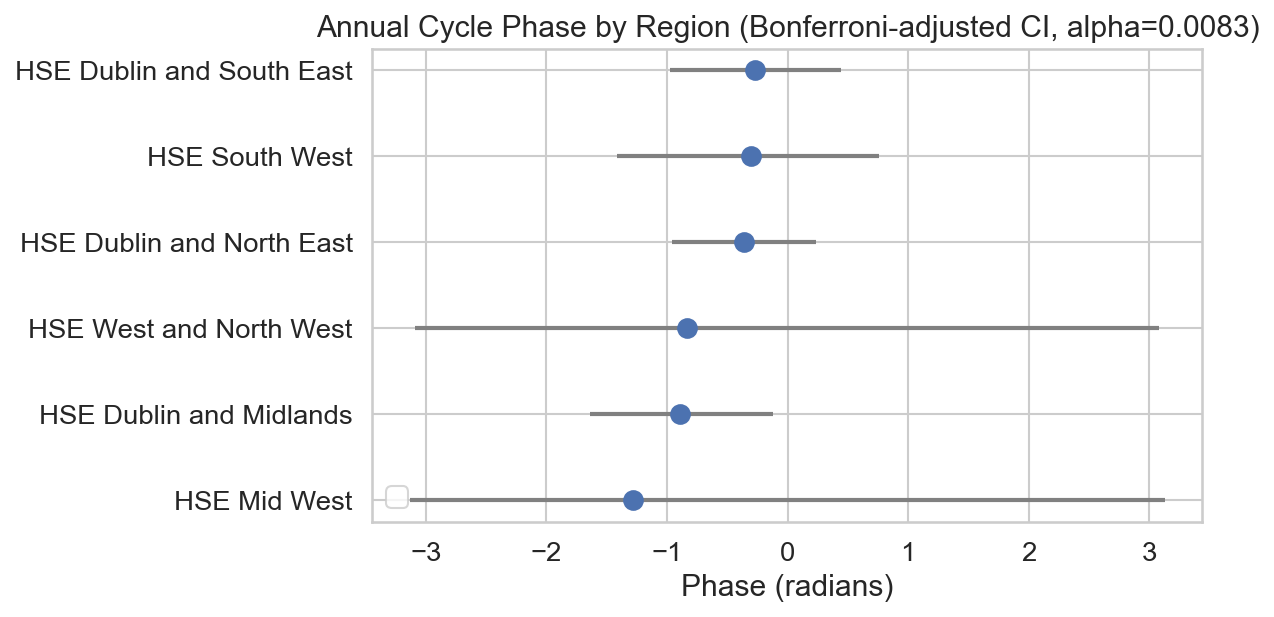

In [339]:
alpha, lower_q, upper_q = calc_bonf(n_region)

# Phase plot
lo_col_phase = f'{lower_q*100:.2f}%'
hi_col_phase = f'{upper_q*100:.2f}%'

df_plot = df_phase_diff.sort_values('Mean')

fig, ax = plt.subplots(figsize=(8, 4), dpi=150, layout='constrained')
y_pos = range(len(df_plot))

ax.hlines(y_pos, df_plot[lo_col_phase], df_plot[hi_col_phase],
          color='grey', linewidth=2, zorder=1)
ax.scatter(df_plot['Mean'], y_pos, s=80, zorder=2)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(df_plot['Region'].values)
ax.set_xlabel('Phase (radians)')
ax.set_title(f'Annual Cycle Phase by Region (Bonferroni-adjusted CI, alpha={alpha:.4f})')
ax.legend(loc='lower left')
plt.show()

### Alpha baseline — pairwise test

In [340]:
# get filtered alphas values
alpha_samples = raw_df.filter(regex='^alpha')

In [341]:
alpha, lower_q, upper_q = calc_bonf(len(list(combinations(range(n_region), 2)))) # get bonferroni corrected quantiles for overall test

results = []
for r1, r2 in combinations(range(n_region), 2):
    diff = alpha_samples[f'alpha[{r1+1}]'] - alpha_samples[f'alpha[{r2+1}]']
    ci_lower, ci_upper = np.quantile(diff, [lower_q, upper_q])
    results.append({
        'Region1': regions[r1],
        'Region2': regions[r2],
        'MeanDiff': diff.mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })
df_alpha_diff = pd.DataFrame(results)
df_alpha_diff

n_comparisons=15, alpha=0.003333, lower_q=0.001667, upper_q=0.998333 (two-sided)


,Region1,Region2,MeanDiff,0.17%,99.83%,Sig
0,HSE Dublin and Midlands,HSE Dublin and North East,1.622664,0.945674,2.276867,Yes
1,HSE Dublin and Midlands,HSE Dublin and South East,0.936961,0.245336,1.627316,Yes
2,HSE Dublin and Midlands,HSE Mid West,-4.192306,-5.235840,-3.118207,Yes
3,HSE Dublin and Midlands,HSE South West,-0.437667,-1.322055,0.445505,No
4,HSE Dublin and Midlands,HSE West and North West,-2.346342,-3.316085,-1.366083,Yes
5,HSE Dublin and North East,HSE Dublin and South East,-0.685703,-1.253711,-0.105410,Yes
6,HSE Dublin and North East,HSE Mid West,-5.814970,-6.776420,-4.799566,Yes
7,HSE Dublin and North East,HSE South West,-2.060331,-2.842590,-1.248352,Yes
8,HSE Dublin and North East,HSE West and North West,-3.969007,-4.850426,-3.049961,Yes
9,HSE Dublin and South East,HSE Mid West,-5.129268,-6.112552,-4.112638,Yes


### New years overall
weeks:
52/1/2

In [342]:
alpha, lower_q, upper_q = calc_bonf(3) # get bonferroni corrected quantiles for overall test

# Full reset pre/mid/post samples (no region index since shared)                                                                                                                 
delta_samples = raw_df[['delta_pre', 'delta_mid', 'delta_post']]                         
params = ['delta_pre', 'delta_mid', 'delta_post']   

results = []
for param in params:
    ci_lower, ci_upper = np.quantile(delta_samples[param], [lower_q, upper_q])
    results.append({
        'Parameter': param,
        'Mean': delta_samples[param].mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })

df_ind = pd.DataFrame(results).round(3)
df_ind


n_comparisons=3, alpha=0.016667, lower_q=0.008333, upper_q=0.991667 (two-sided)


,Parameter,Mean,0.83%,99.17%,Sig
0,delta_pre,-1.449,-1.962,-0.932,Yes
1,delta_mid,-3.340,-3.846,-2.849,Yes
2,delta_post,0.120,-0.321,0.561,No


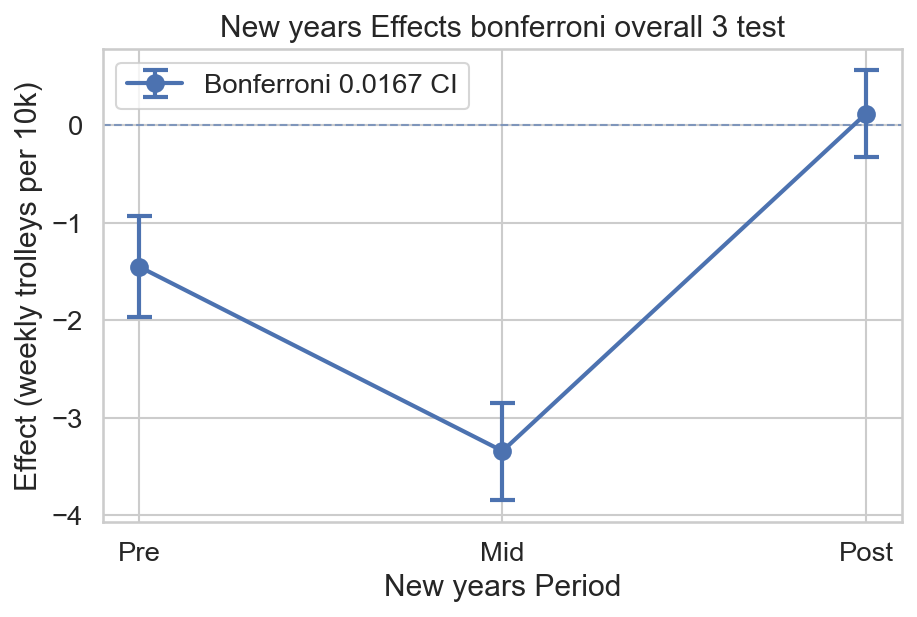

In [350]:
lo_col = f'{lower_q*100:.2f}%'
hi_col = f'{upper_q*100:.2f}%'

labels = ['Pre', 'Mid', 'Post']
means = df_ind['Mean'].values
ci_lo = df_ind[lo_col].values
ci_hi = df_ind[hi_col].values
yerr_lower = means - ci_lo
yerr_upper = ci_hi - means

fig, ax = plt.subplots(figsize=(6, 4), dpi=150, layout='constrained')
ax.errorbar(labels, means, yerr=[yerr_lower, yerr_upper],
            fmt='o-', linewidth=2, markersize=8,
            capsize=6, capthick=2, elinewidth=2, zorder=3,
            label=f'Bonferroni {alpha:.4f} CI')
ax.axhline(0, linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('New years Period')
ax.set_ylabel('Effect (weekly trolleys per 10k)')
ax.set_title(f'New years Effects bonferroni overall 3 test')
ax.legend()
plt.show()

### Delta new years pairwise

In [344]:
# Pairwise: C(3,2) = 3 tests, bonferroni corrected
pairs = list(combinations(params, 2))
alpha, lower_q, upper_q = calc_bonf(len(pairs)) # get bonferroni corrected quantiles for overall test

results = []
for a, b in pairs:
    diff = delta_samples[a] - delta_samples[b]
    ci_lower, ci_upper = np.quantile(diff, [lower_q, upper_q])
    results.append({
        'Comparison': f'{a} - {b}',
        'MeanDiff': diff.mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })

print(f"\nPairwise tests - Bonferroni alpha: {alpha:.6f})")
df_pw = pd.DataFrame(results).round(3)
df_pw

n_comparisons=3, alpha=0.016667, lower_q=0.008333, upper_q=0.991667 (two-sided)

Pairwise tests - Bonferroni alpha: 0.016667)


,Comparison,MeanDiff,0.83%,99.17%,Sig
0,delta_pre - delta_mid,1.891,1.359,2.423,Yes
1,delta_pre - delta_post,-1.569,-2.170,-0.972,Yes
2,delta_mid - delta_post,-3.460,-3.943,-2.985,Yes


### Full reset overall

In [345]:
alpha, lower_q, upper_q = calc_bonf(3) # get bonferroni corrected quantiles for overall test

# New year pre/mid/post sigma samples (SD of effect)
sigma_samples = raw_df[['sigma_pre', 'sigma_mid', 'sigma_post']]
sigma_params = ['sigma_pre', 'sigma_mid', 'sigma_post']

results = []
for param in sigma_params:
    ci_lower, ci_upper = np.quantile(sigma_samples[param], [lower_q, upper_q])
    results.append({
        'Parameter': param,
        'Mean': sigma_samples[param].mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })

print(f"Individual tests - Bonferroni alpha={alpha:.6f}")
df_sig_ind = pd.DataFrame(results).round(3)
df_sig_ind

n_comparisons=3, alpha=0.016667, lower_q=0.008333, upper_q=0.991667 (two-sided)
Individual tests - Bonferroni alpha=0.016667


,Parameter,Mean,0.83%,99.17%,Sig
0,sigma_pre,-4.196,-7.269,-1.127,Yes
1,sigma_mid,-7.219,-10.674,-3.798,Yes
2,sigma_post,-3.690,-6.767,-0.626,Yes


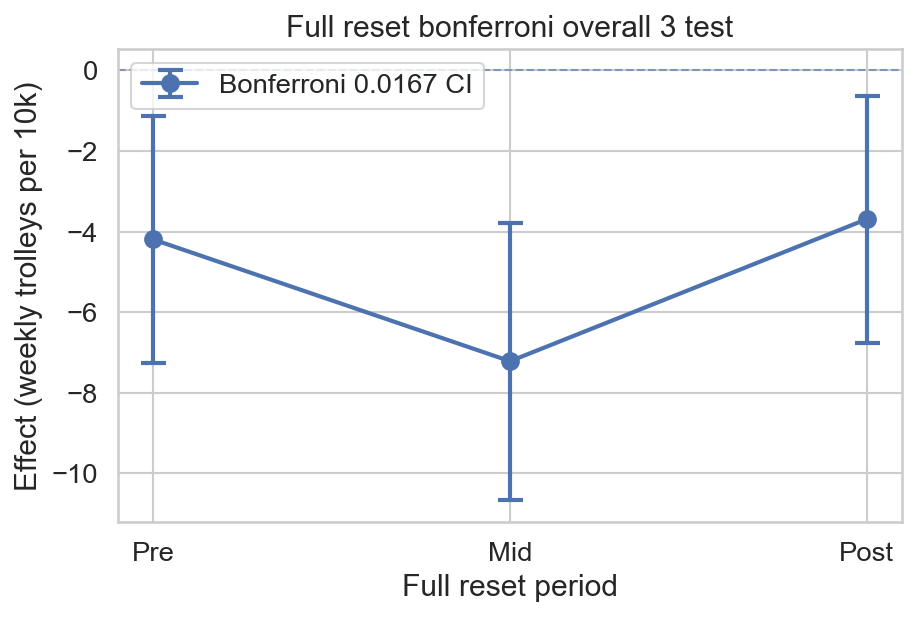

In [351]:
means = df_sig_ind.iloc[:,1].values
yerr_lower = means - df_sig_ind.iloc[:, 2].values
yerr_upper = df_sig_ind.iloc[:, 3].values - means

fig, ax = plt.subplots(figsize=(6, 4), dpi=150, layout='constrained')
ax.errorbar(['Pre', 'Mid', 'Post'],  
            df_sig_ind['Mean'].values, 
            yerr=[yerr_lower, yerr_upper],
            fmt='o-', linewidth=2, markersize=8,
            capsize=6, capthick=2, elinewidth=2, zorder=3,
            label=f'Bonferroni {alpha:.4f} CI')
ax.axhline(0, linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('Full reset period')
ax.set_ylabel('Effect (weekly trolleys per 10k)')
ax.set_title(f'Full reset bonferroni overall 3 test')
ax.legend()
plt.show()